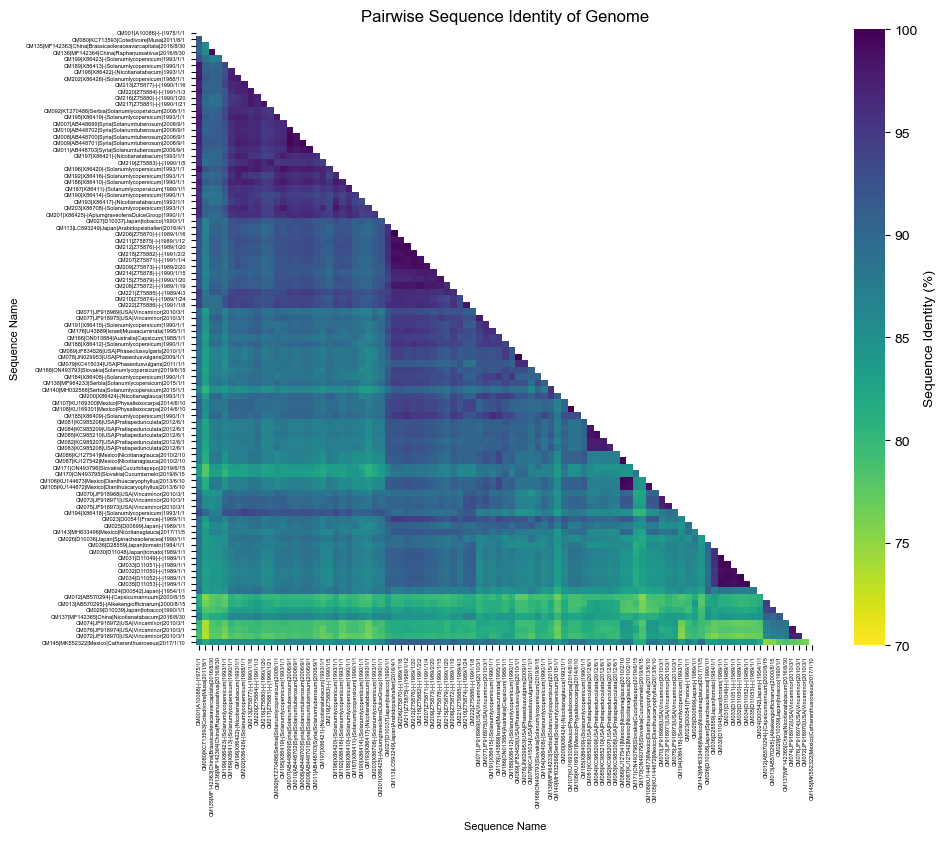

In [15]:
import matplotlib as mpl
from matplotlib.font_manager import FontProperties
mpl.rcParams['svg.fonttype'] = 'none'
# Path to your Arial.ttf file
arial_font_path = '/Users/skawakubo/python/fonts/Arial.ttf'
# Create a FontProperties object for the Arial font
arial_font = FontProperties(fname=arial_font_path)
mpl.rcParams['font.family'] = arial_font.get_name()

from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_pairwise_identity(seq_list, alignment_length):
    """
    Calculate pairwise sequence identity percentage, using the full MSA length.
    
    Args:
        seq_list (list of str): List of sequences from the MSA.
        alignment_length (int): The length of the multiple sequence alignment.
    
    Returns:
        np.array: A matrix of pairwise sequence identity percentages.
    """
    num_sequences = len(seq_list)
    identity_matrix = np.zeros((num_sequences, num_sequences), dtype=float)
    
    for i in range(num_sequences):
        for j in range(i+1, num_sequences):
            # Count identical positions (excluding gaps if necessary)
            matches = sum(1 for a, b in zip(seq_list[i], seq_list[j]) if a == b)
            
            # Use the alignment length as denominator (fixed for all comparisons)
            identity_matrix[i, j] = (matches / alignment_length) * 100
            identity_matrix[j, i] = identity_matrix[i, j]  # Symmetric matrix
    
    np.fill_diagonal(identity_matrix, 100)  # Self-comparisons are 100%
    return identity_matrix

seq_path = "/Users/skawakubo/Library/CloudStorage/Dropbox/HU/CMV_satellite/AlignmentImage_CMVsat/CMVsat_filtered_seq_selected_pos_reordered2.fas"
sequences = list(SeqIO.parse(seq_path, "fasta"))
seq_list = [str(seq.seq).replace('N', '-') for seq in sequences]
seq_names = [seq.id for seq in sequences]

# Get the alignment length (all sequences should have the same length in an MSA)
alignment_length = len(seq_list[0])  # Assumes all sequences in the MSA have equal length

identity_matrix = calculate_pairwise_identity(seq_list, alignment_length)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(identity_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(identity_matrix, mask=mask, annot=False, cmap="viridis_r", 
            cbar_kws={'label': 'Sequence Identity (%)'}, 
            xticklabels=seq_names, yticklabels=seq_names, vmin=70, vmax=100)

plt.title('Pairwise Sequence Identity of Genome')
plt.xlabel('Sequence Name', fontsize=8)
plt.ylabel('Sequence Name', fontsize=8)
plt.xticks(rotation=90)
plt.tick_params(axis='both', which='major', labelsize=4)
# plt.show()

# Save as PDF
plt.savefig("/Users/skawakubo/Library/CloudStorage/Dropbox/HU/CMV_satellite/AlignmentImage_CMVsat/CMVsat_identity2.svg", bbox_inches='tight')

In [4]:
# find the minimum value
min_value = np.min(identity_matrix[identity_matrix>0])
print(min_value)

75.0
